In [1]:
# Install & imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

print("All imports successful")

All imports successful


In [2]:
# Upload file
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [3]:
# Load data & first look
df = pd.read_csv('Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7,043 customers, 21 columns. The key ones to know:
tenure - how many months they've been a customer. This will be the most powerful feature.
MonthlyCharges / TotalCharges - how much they pay. High monthly + low tenure = high risk.
Contract - Month-to-month customers churn way more than annual contracts.
Churn - our target variable. Yes/No. This is what the model will predict.

Rows 2 and 4 - both have tenure = 2 (brand new customers) and both churned. That's already a pattern.

In [4]:
# Data quality check
print(" Missing Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

print("\nChurn Distribution")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

 Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        

TotalCharges is listed as object (text) but it should be float64 like MonthlyCharges. That means there are hidden spaces " " in that column masquerading as values classic dirty data trick that would silently break the model later.
26.5% churn rate is also important context in our dataset is imbalanced. About 3 non-churners for every churner.

In [5]:
# Data cleaning
# Fix TotalCharges convert to numeric, spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs appeared
print("TotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())

# Drop those rows (there are only 11 — safe to remove)
df = df.dropna(subset=['TotalCharges'])

# Convert Churn to binary 0/1 for modeling later
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert SeniorCitizen to readable label
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("Clean dataset shape:", df.shape)
print("\nTotalCharges dtype now:", df['TotalCharges'].dtype)
print("\nChurn_Binary sample:")
print(df['Churn_Binary'].value_counts())

TotalCharges nulls after fix: 11
Clean dataset shape: (7032, 22)

TotalCharges dtype now: float64

Churn_Binary sample:
Churn_Binary
0    5163
1    1869
Name: count, dtype: int64


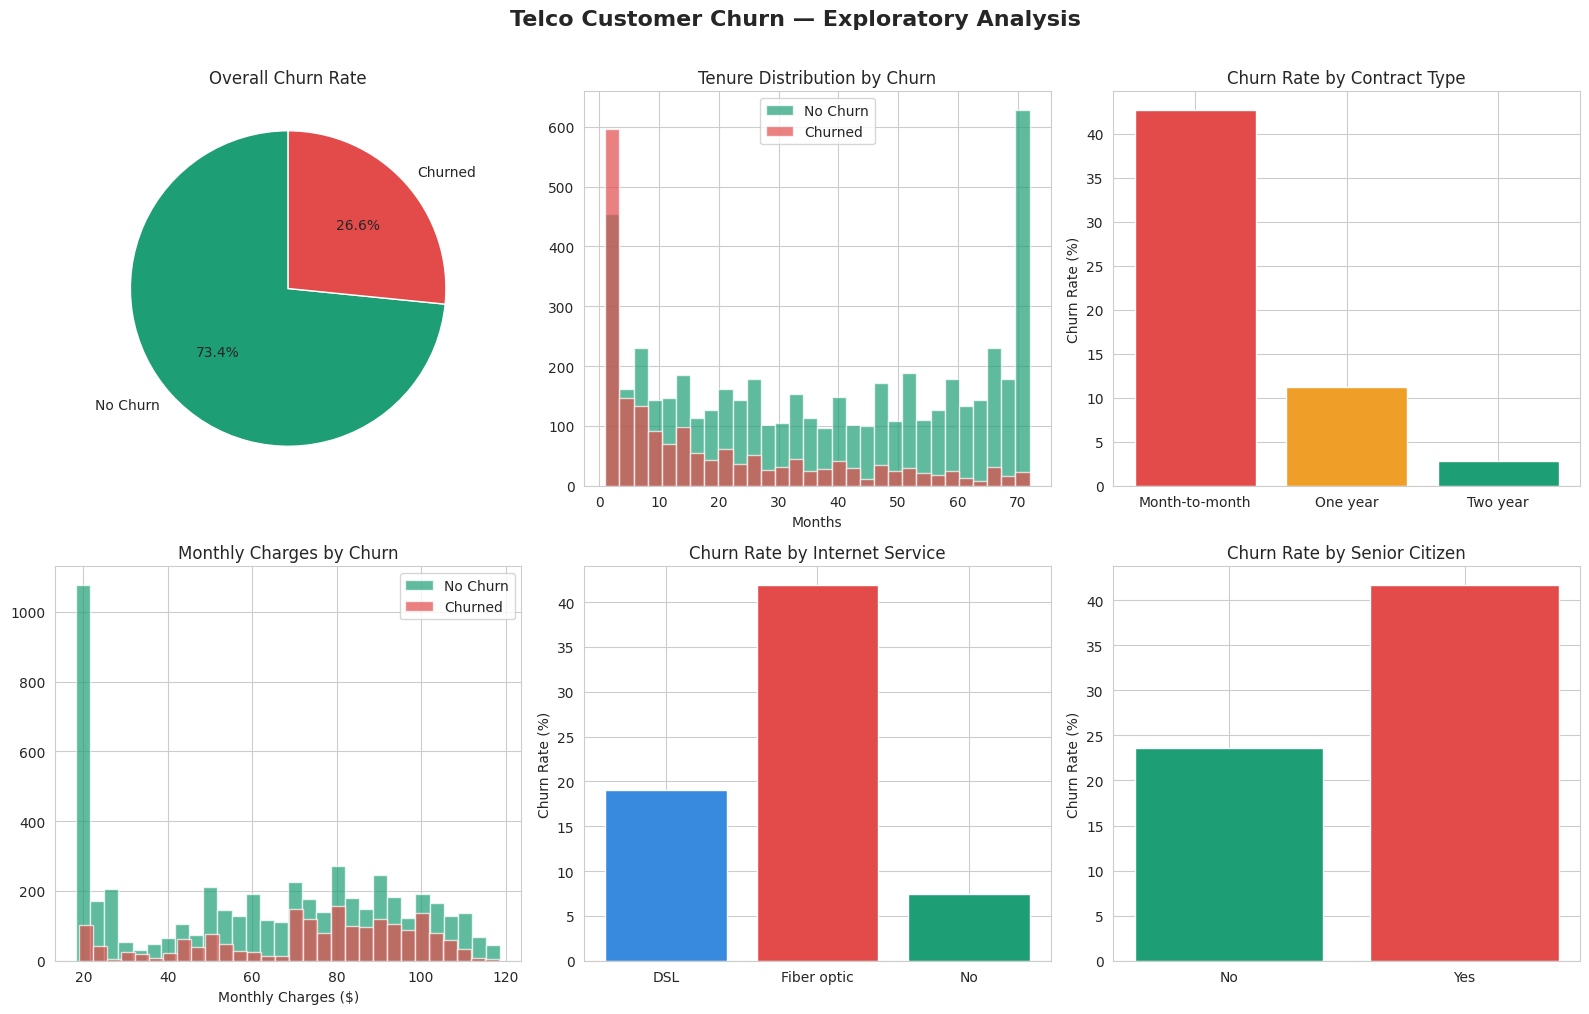

Chart saved as eda_charts.png 


In [6]:
# EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Customer Churn — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)

# 1. Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn', 'Churned'], autopct='%1.1f%%',
              colors=['#1D9E75', '#E24B4A'], startangle=90)
axes[0,0].set_title('Overall Churn Rate')

# 2. Tenure vs Churn
axes[0,1].hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.7,
               color='#1D9E75', label='No Churn')
axes[0,1].hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.7,
               color='#E24B4A', label='Churned')
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Months')
axes[0,1].legend()

# 3. Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
axes[0,2].bar(contract_churn.index, contract_churn.values,
              color=['#E24B4A', '#EF9F27', '#1D9E75'])
axes[0,2].set_title('Churn Rate by Contract Type')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].set_xlabel('')

# 4. Monthly Charges vs Churn
axes[1,0].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.7,
               color='#1D9E75', label='No Churn')
axes[1,0].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.7,
               color='#E24B4A', label='Churned')
axes[1,0].set_title('Monthly Charges by Churn')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# 5. Internet Service vs Churn
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
axes[1,1].bar(internet_churn.index, internet_churn.values,
              color=['#378ADD', '#E24B4A', '#1D9E75'])
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_ylabel('Churn Rate (%)')

# 6. Senior Citizen vs Churn
senior_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
axes[1,2].bar(senior_churn.index, senior_churn.values,
              color=['#1D9E75', '#E24B4A'])
axes[1,2].set_title('Churn Rate by Senior Citizen')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as eda_charts.png ")

## Key EDA Findings

1. **Contract type is the dominant churn driver**  month-to-month customers
   churn at 42%, vs 11% (one year) and 3% (two year). A 14x difference.

2. **Churn is an early-lifecycle problem**  the majority of churned customers
   leave within the first 10 months. Retention efforts should focus here.

3. **Higher monthly charges correlate with churn**  churned customers
   concentrate in the 60 -$100/month range.

4. **Fiber optic is a red flag**  42% churn rate suggests a pricing or
   service quality issue specific to this product line.

5. **Senior citizens are high-risk** churn rate nearly double that of
   non-seniors (42% vs 24%).

### Business Implication
A new fiber optic customer on a month-to-month contract in their first
6 months is the highest-risk profile in this dataset. Retention campaigns
should prioritize this segment immediately.

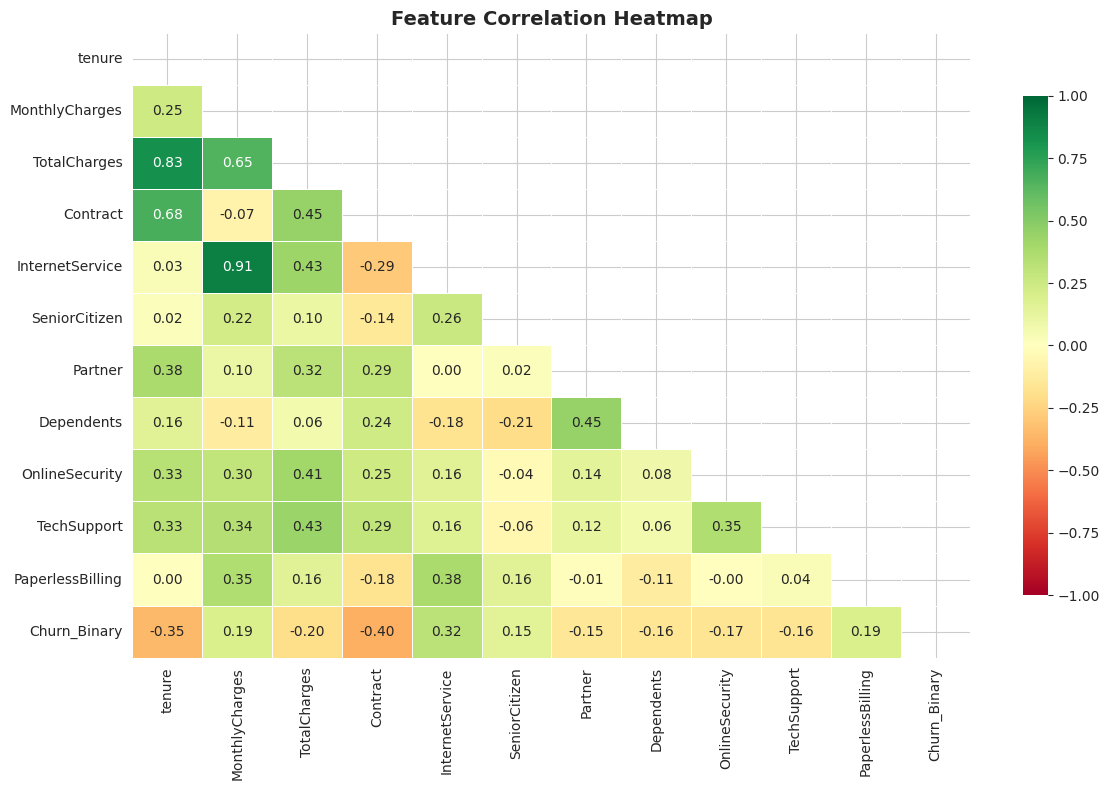

Heatmap saved


In [7]:
# Correlation Heatmap
# First encode categorical columns numerically for correlation
df_corr = df.copy()

# Encode binary yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0,
                                      'No phone service': 0,
                                      'No internet service': 0})

# Encode contract and internet service
df_corr['Contract'] = df_corr['Contract'].map({'Month-to-month': 0,
                                                'One year': 1,
                                                'Two year': 2})
df_corr['InternetService'] = df_corr['InternetService'].map({'No': 0,
                                                              'DSL': 1,
                                                              'Fiber optic': 2})
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].map({'Yes': 1, 'No': 0})

# Select numeric columns only
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
            'InternetService', 'SeniorCitizen', 'Partner', 'Dependents',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'Churn_Binary']

corr_matrix = df_corr[num_cols].corr()

# Plot
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved")

In [8]:
#  Build features for segmentation
# We'll segment on 3 key dimensions: tenure, MonthlyCharges, TotalCharges
# These capture HOW LONG, HOW MUCH/MONTH, and HOW MUCH TOTAL

features = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

# Scale the features — K-Means is distance-based so scale matters
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Features shape:", features_scaled.shape)
print("\nRaw feature stats:")
print(features[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

Features shape: (7032, 3)

Raw feature stats:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80


Contract -0.40 - strongest negative correlation. Longer contract = much less churn.
tenure -0.35 - longer customer = less churn. Confirmed.
MonthlyCharges +0.19 - higher bill = more churn. Confirmed.
InternetService +0.32 - fiber optic driving this up.

Also notice MonthlyCharges - InternetService = 0.91 - almost perfectly correlated. Fiber optic customers pay way more. That explains the fiber churn problem - it's a pricing issue.

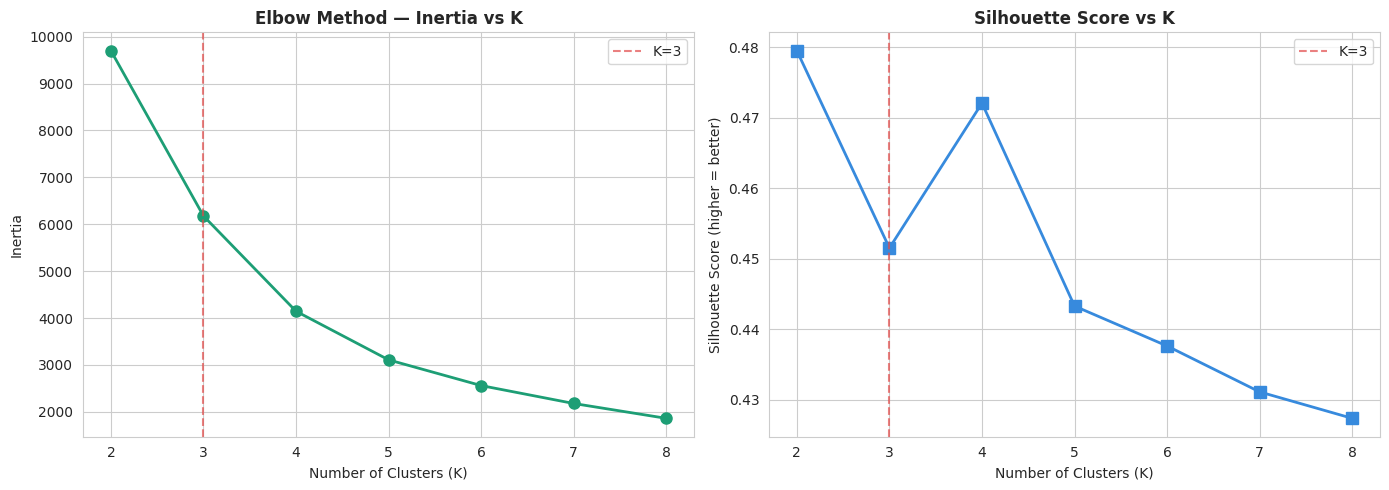

Silhouette Scores:
  K=2: 0.4795
  K=3: 0.4515
  K=4: 0.4721
  K=5: 0.4433
  K=6: 0.4376
  K=7: 0.4311
  K=8: 0.4273


In [9]:
# Elbow method to find optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

# Plot both metrics side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'o-', color='#1D9E75', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='#E24B4A', linestyle='--', alpha=0.7, label='K=3')
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 's-', color='#378ADD', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(x=3, color='#E24B4A', linestyle='--', alpha=0.7, label='K=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the scores
print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  K={k}: {score:.4f}")

Interesting result! K=2 technically wins on silhouette (0.4795).

In [10]:
# Run K-Means with K=3 and label the segments
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Analyze each cluster to assign meaningful labels
cluster_summary = df.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Avg_TotalCharges=('TotalCharges', 'mean'),
    Churn_Rate=('Churn_Binary', 'mean')
).round(2)

cluster_summary['Churn_Rate_%'] = (cluster_summary['Churn_Rate'] * 100).round(1)
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         Count  Avg_Tenure  Avg_MonthlyCharges  Avg_TotalCharges  Churn_Rate  \
Cluster                                                                        
0         2151       29.62               26.63            815.26        0.12   
1         2197       58.57               89.74           5249.43        0.15   
2         2684       13.26               74.97           1031.88        0.47   

         Churn_Rate_%  
Cluster                
0                12.0  
1                15.0  
2                47.0  


Cluster 0, 29 months tenure, 27/month, 12% churn to  Budget Loyalists. Long-ish tenure but low spenders. Stable.
Cluster 1, 59 months tenure, 90/month, 15% churn to Champions. The best customers. High value, highly retained.
Cluster 2, 13 months tenure, 75/month, 47% churn to At-Risk. New customers paying a lot, leaving fast. This is you target segment.

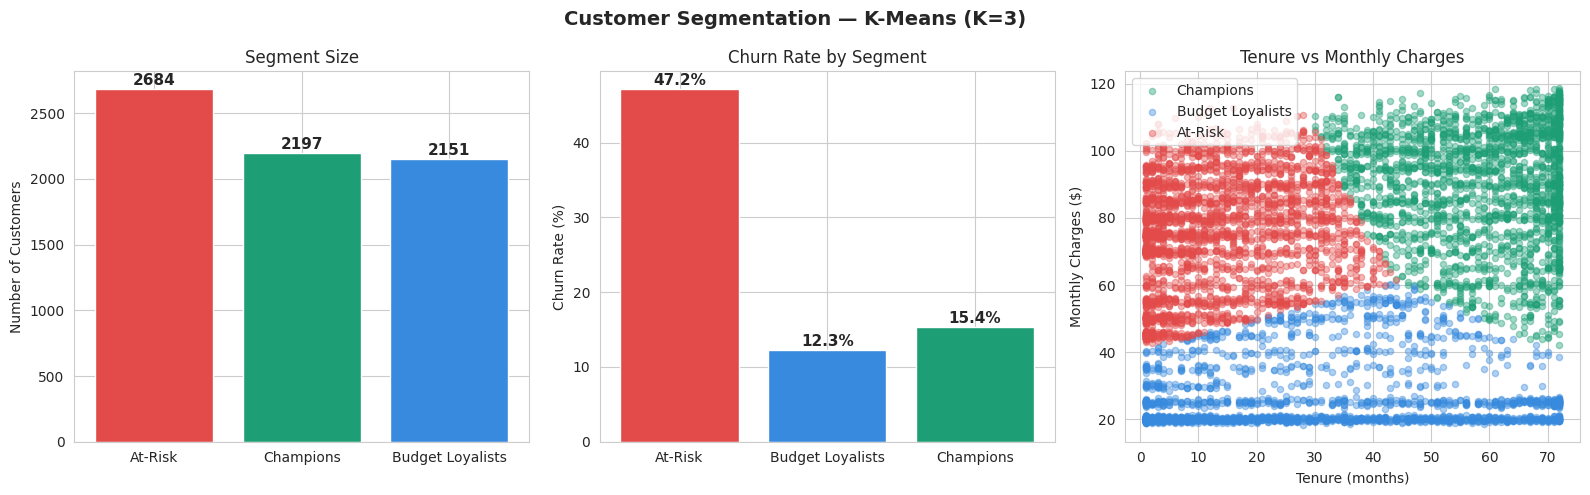


SEGMENT SUMMARY 
                  Count  Avg_Tenure  Avg_Monthly  Churn_Rate
Segment                                                     
At-Risk            2684       13.26        74.97        0.47
Budget Loyalists   2151       29.62        26.63        0.12
Champions          2197       58.57        89.74        0.15

Segmented dataset saved as telco_churn_segmented.csv 


In [11]:
# Label clusters and visualize
segment_map = {0: 'Budget Loyalists', 1: 'Champions', 2: 'At-Risk'}
df['Segment'] = df['Cluster'].map(segment_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segmentation — K-Means (K=3)', fontsize=14, fontweight='bold')

colors = {'Champions': '#1D9E75', 'Budget Loyalists': '#378ADD', 'At-Risk': '#E24B4A'}

# 1. Segment sizes
segment_counts = df['Segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values,
            color=[colors[s] for s in segment_counts.index])
axes[0].set_title('Segment Size')
axes[0].set_ylabel('Number of Customers')
for i, (seg, val) in enumerate(segment_counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=11, fontweight='bold')

# 2. Churn rate by segment
churn_by_seg = df.groupby('Segment')['Churn_Binary'].mean() * 100
axes[1].bar(churn_by_seg.index, churn_by_seg.values,
            color=[colors[s] for s in churn_by_seg.index])
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate (%)')
for i, (seg, val) in enumerate(churn_by_seg.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 3. Scatter — Tenure vs Monthly Charges colored by segment
for seg, color in colors.items():
    mask = df['Segment'] == seg
    axes[2].scatter(df[mask]['tenure'], df[mask]['MonthlyCharges'],
                    c=color, label=seg, alpha=0.4, s=20)
axes[2].set_title('Tenure vs Monthly Charges')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Monthly Charges ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Final summary print
print("\nSEGMENT SUMMARY ")
print(df.groupby('Segment').agg(
    Count=('Segment', 'count'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_Monthly=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn_Binary', 'mean')
).round(2))

# Save enriched dataset
df.to_csv('telco_churn_segmented.csv', index=False)
print("\nSegmented dataset saved as telco_churn_segmented.csv ")

In [12]:
from google.colab import files
files.download('telco_churn_segmented.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>